In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib_venn import venn3

In [ ]:
raw_motion_data = pd.read_excel("data/Motion full matched_for_olga.xlsx", header=1)

motion_data = raw_motion_data.replace('-', np.nan)
radius_columns = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']
tibia_columns = [f"{x}.1" for x in radius_columns]

motion_data[radius_columns] = motion_data[radius_columns].astype(float)
motion_data[tibia_columns] = motion_data[tibia_columns].astype(float)
motion_data[tibia_columns].head()

In [3]:
str = 'MG_{}_rounded mean'
motion = 'Radius'
print(str.format(motion))

MG_Radius_rounded mean


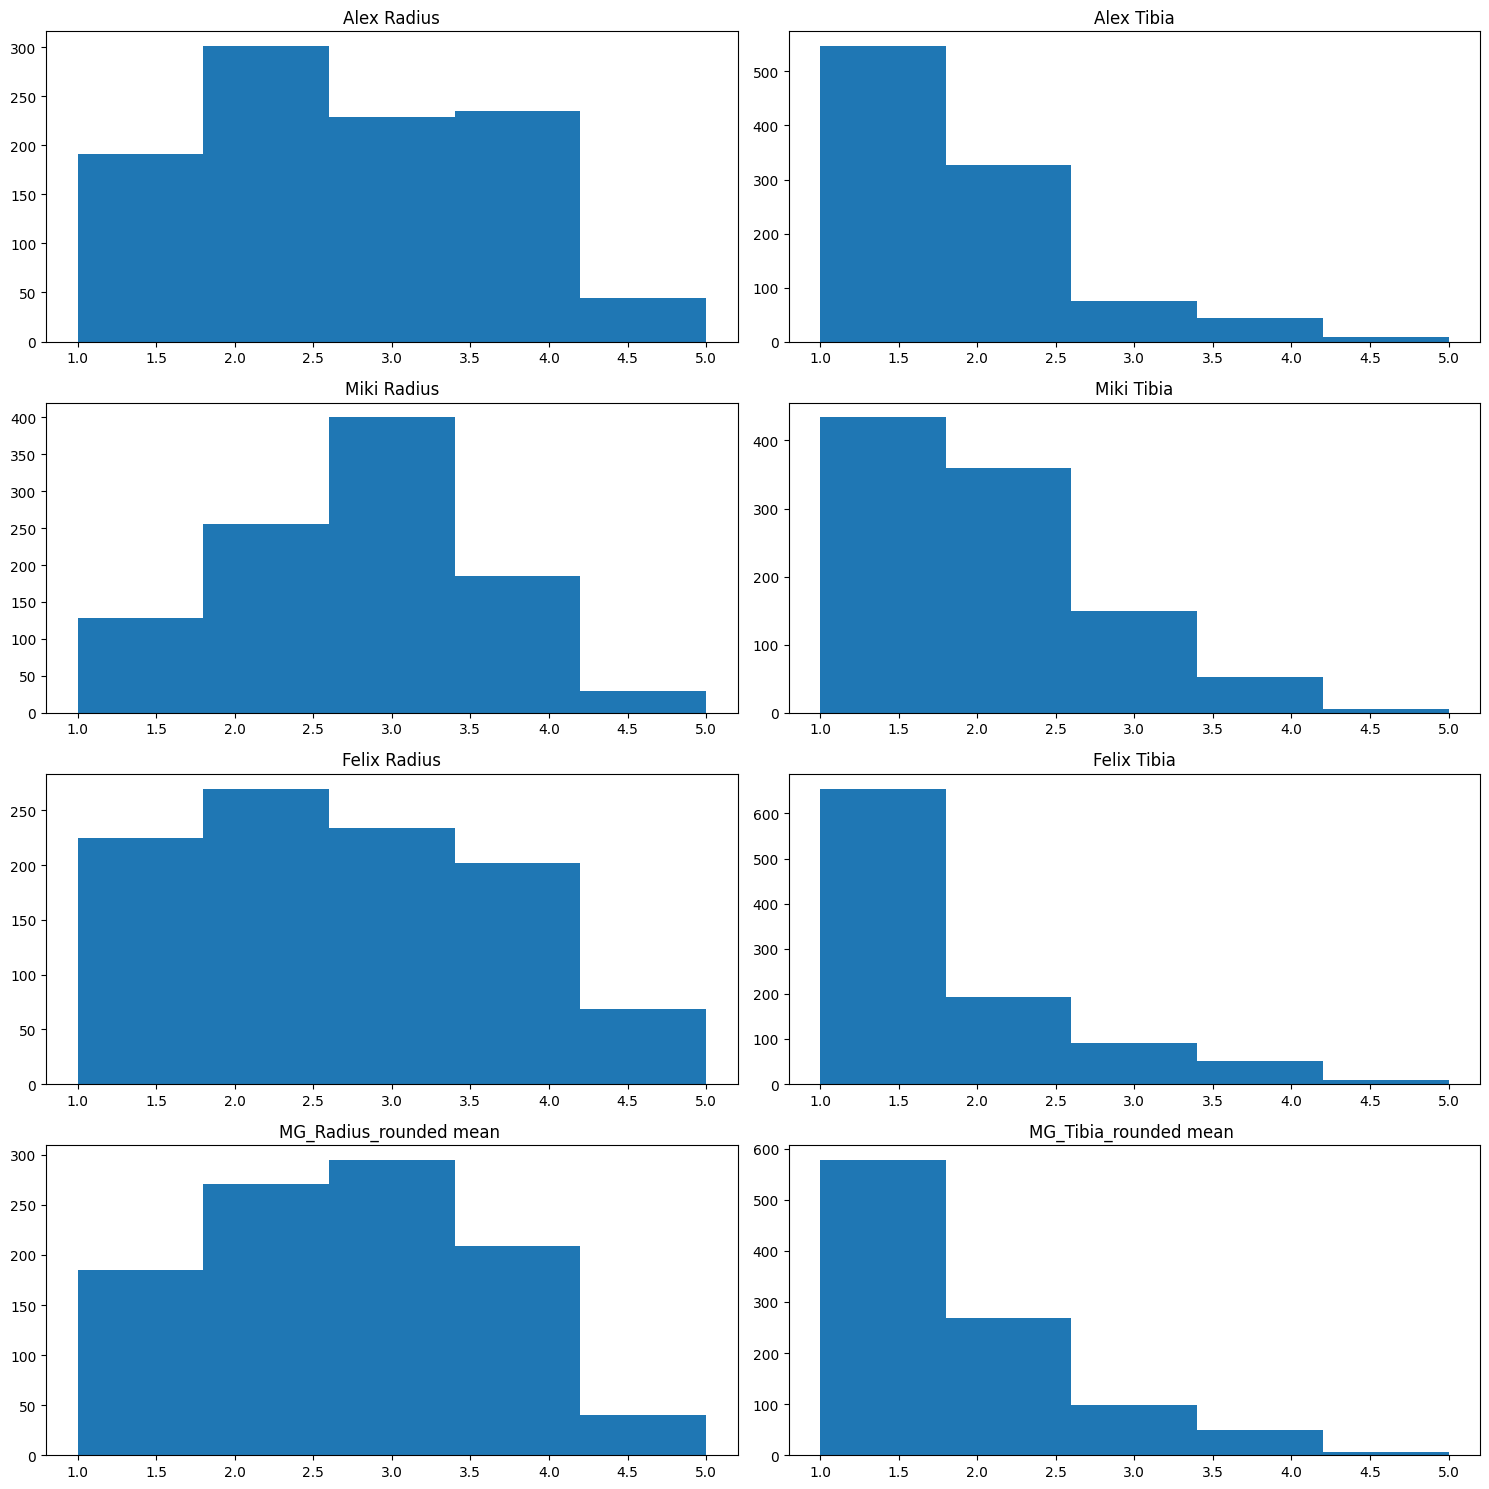

In [4]:
# make subplots for each grader and each motion grade
fig, axs = plt.subplots(4, 2, figsize=(15, 15))
for i, grader in enumerate(['Alex', 'Miki', 'Felix', 'MG_{}_rounded mean']):
    for j, motion in enumerate(['Radius', 'Tibia']):
        data = raw_motion_data[[f'{grader.format(motion.lower())}{".1" if motion == "Tibia" and not grader.startswith("MG") else ""}']]
        axs[i, j].hist(data, bins=5)
        axs[i, j].set_title(f'{grader.format(motion)} {motion if not grader.startswith("MG") else ""}')

fig.tight_layout()
plt.savefig('histograms_data_distribution.png')


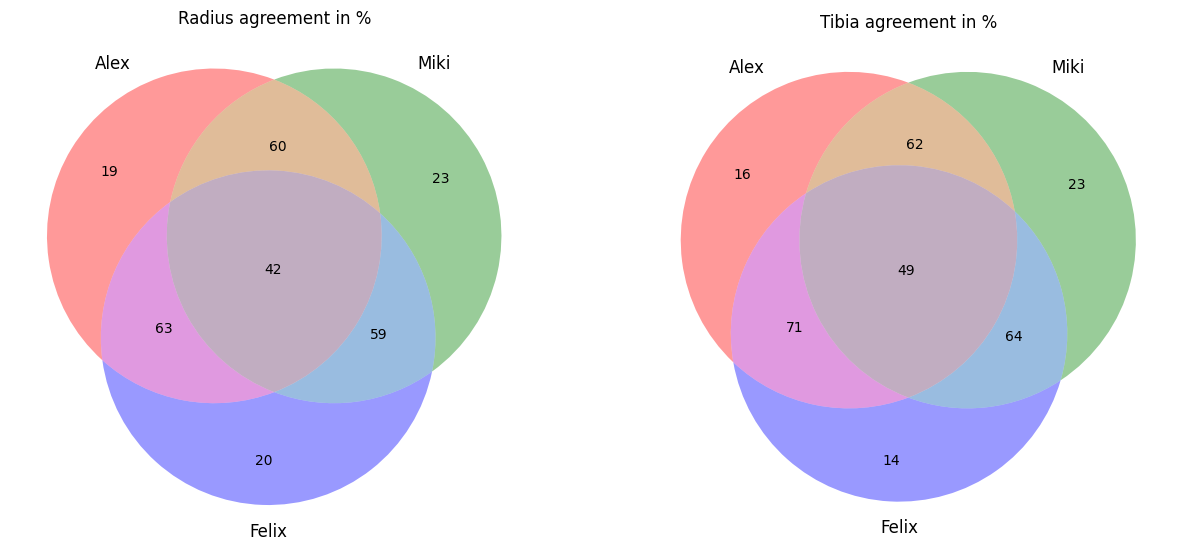

In [5]:
# make venn diagram for tibia and check how well the graders agree
def agree_precents(data, grader1, grader2, grader3: str = None):
    total = len(data)

    if not grader3:
        agree = len(data[(data[grader1] == data[grader2])])
    else:
        agree = len(data[(data[grader1] == data[grader2]) & (data[grader1] == data[grader3])])

    return int(agree / total * 100)

# make venn diagram twice for radius and tibia
fig, axs = plt.subplots(1, 2, figsize=(15, 10))
for i, motion in enumerate(['Radius', 'Tibia']):
    if motion == 'Radius':
        graders = ['Alex', 'Miki', 'Felix']
    else:
        graders = ['Alex.1', 'Miki.1', 'Felix.1']
    data = raw_motion_data[graders]
    alex_miki = agree_precents(data, grader1=graders[0], grader2=graders[1])
    alex_felix = agree_precents(data, grader1=graders[0], grader2=graders[2])
    miki_felix = agree_precents(data, grader1=graders[1], grader2=graders[2])
    alex_miki_felix = agree_precents(data, grader1=graders[0], grader2=graders[1], grader3=graders[2])

    alex_only = 100 - alex_miki - alex_felix + alex_miki_felix
    miki_only = 100 - alex_miki - miki_felix + alex_miki_felix
    felix_only = 100 - alex_felix - miki_felix + alex_miki_felix

    venn3(subsets=(alex_only, miki_only, alex_miki, felix_only, alex_felix, miki_felix, alex_miki_felix),
               set_labels=('Alex', 'Miki', 'Felix'), ax=axs[i])
    axs[i].set_title(f'{motion} agreement in %')


In [1]:
# check out the disagreements between graders as a lollipop plot
def disagreement_plot(data, grader1, grader2, motion):
    disagreements = data[data[grader1] != data[grader2]].copy()
    # remove disagreements where the graders are just 1 off
    disagreements.reset_index(drop=True, inplace=True)
    print(len(disagreements), 'disagreements between', grader1, 'and', grader2, 'for', motion)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.vlines(x=disagreements.index, ymin=disagreements[grader2], ymax=disagreements[grader1], color='dodgerblue', linewidth=2, label=grader1)
    ax.scatter(disagreements.index, disagreements[grader1], color='dodgerblue', s=100)

    ax.vlines(x=disagreements.index, ymin=disagreements[grader1], ymax=disagreements[grader2], color='darkorange', linewidth=2, label=grader2)
    ax.scatter(disagreements.index, disagreements[grader2], color='darkorange', s=100)
    ax.set_ylim(1, 5)
    plt.xlabel('Sample Index')
    plt.ylabel('Difference')
    plt.grid()
    plt.show()

# Create disagreement plots for Radius and Tibia
for motion in ['Radius', 'Tibia']:
    if motion == 'Radius':
        graders = ['Alex', 'Miki', 'Felix']
    else:
        graders = ['Alex.1', 'Miki.1', 'Felix.1']
    
    disagreement_plot(raw_motion_data, graders[0], graders[1], motion)
    disagreement_plot(raw_motion_data, graders[0], graders[2], motion)
    disagreement_plot(raw_motion_data, graders[1], graders[2], motion)



NameError: name 'raw_motion_data' is not defined

In [ ]:
# Count how often each grade shows up and give percentage
def grade_counts(data, grader):
    return data[grader].value_counts(normalize=True) * 100

print(grade_counts(raw_motion_data, 'MG_radius_rounded mean'))
print(grade_counts(raw_motion_data, 'MG_tibia_rounded mean'))

MG_radius_rounded mean
3    29.5
2    27.1
4    20.9
1    18.5
5     4.0
Name: proportion, dtype: float64
MG_tibia_rounded mean
1    57.8
2    26.8
3     9.9
4     4.9
5     0.6
Name: proportion, dtype: float64


## Removing Miki

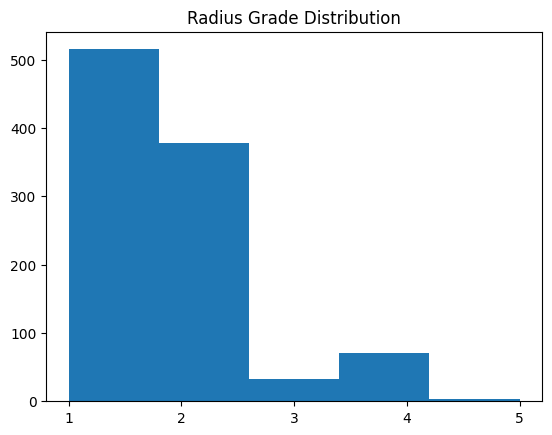

MG_tibia_rounded mean no Miki
1    51.5
2    37.8
4     7.0
3     3.3
5     0.4
Name: proportion, dtype: float64


In [ ]:

grader_column = f'MG_tibia_rounded mean no Miki'
# add column that combines the two other graders via a mean
graders = ['Alex.1', 'Felix.1']
motion_data[grader_column] = motion_data[graders].mean(axis=1)
motion_data[grader_column] = motion_data[grader_column].round()
motion_data[grader_column] = motion_data[grader_column].astype(int)

# draw histogram for the new grader_column
plt.hist(motion_data[grader_column], bins=5)
plt.title(f'Radius Grade Distribution')
plt.xticks(np.arange(1, 6, 1), ['1', '2', '3', '4', '5'])
plt.show()


print(grade_counts(motion_data, grader_column))

## Separating the old and new machines

In [ ]:
BONE = 'Tibia'

if BONE == 'Tibia':
    graders = ['Alex.1', 'Felix.1']
    motion_data[grader_column] = motion_data[graders].mean(axis=1)
    motion_data[grader_column] = motion_data[grader_column].round()
    motion_data[grader_column] = motion_data[grader_column].astype(int)


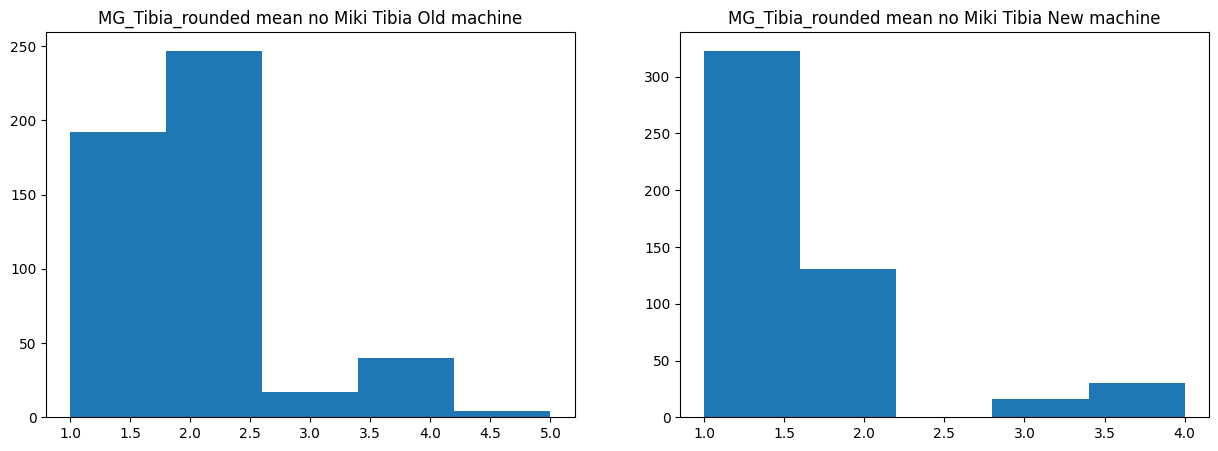

In [ ]:
# split the data into two groups: one where Ct.Po is nan and one where it is not
nan_data = motion_data[motion_data['Ct.Po'].isna()]
not_nan_data = motion_data[motion_data['Ct.Po'].notna()]

# plot the grades of the new grader_column for the two groups
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
for i, data in enumerate([nan_data, not_nan_data]):
    axs[i].hist(data[grader_column], bins=5)
    axs[i].set_title(f'{grader_column} Tibia {"Old machine" if i == 0 else "New machine"}')

plt.show()

/tmp/ipykernel_1311495/1879265173.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', 5)  # Discrete colormap with 5 colors


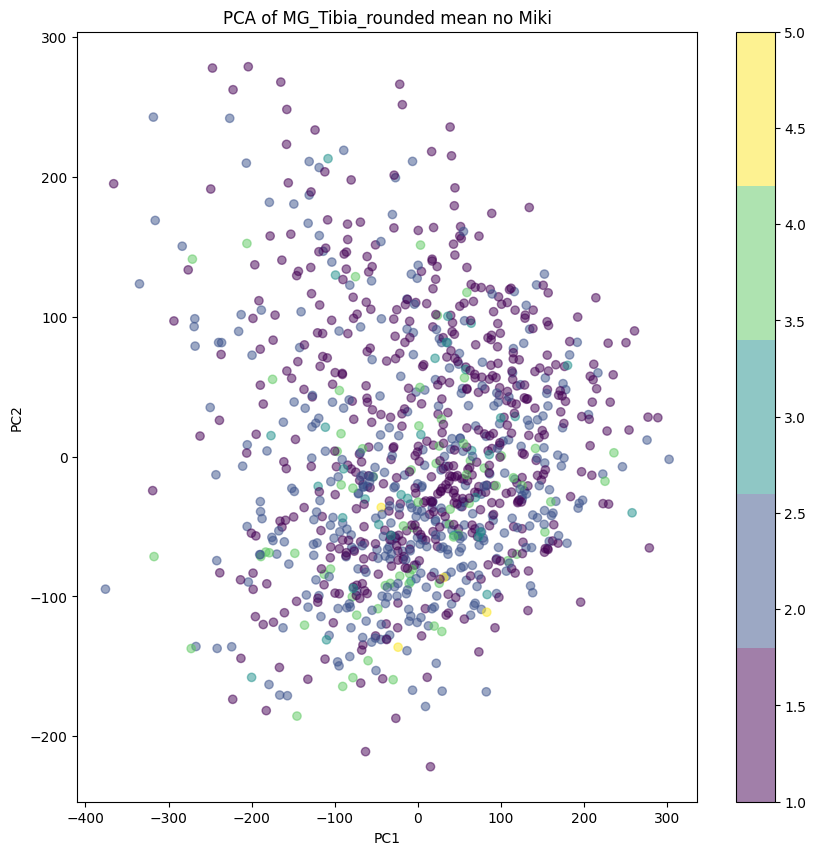

In [ ]:
# show pca plot of the radius data coloured by MG_Radius_rounded mean no Miki
def pca_plot(data, column):
    # replace Nan with 0
    data = data.fillna(0)
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(data[radius_columns])
    plt.figure(figsize=(10, 10))
    cmap = plt.cm.get_cmap('viridis', 5)  # Discrete colormap with 5 colors
    scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=data[column], cmap=cmap, alpha=0.5)
    plt.colorbar()
    plt.title(f'PCA of {column}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()
pca_plot(motion_data, grader_column)



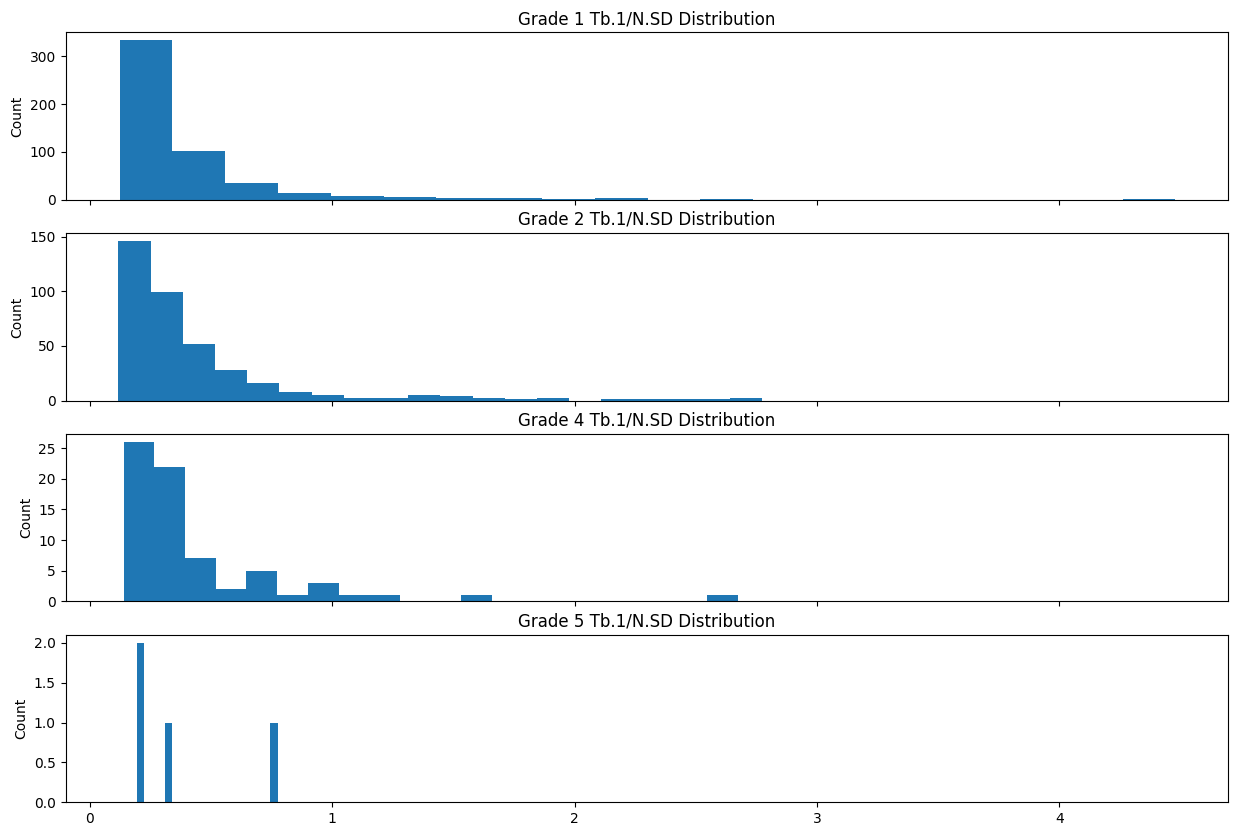

In [ ]:
# show value distribution of Tb.N for grades 1,2 and 4,5
def show_distribution(data, column, feature):
    fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex='all')

    for i, grade in enumerate([1, 2, 4, 5]):
        data_grade = data[data[column] == grade]
        ax[i].hist(data_grade[feature], bins=20)
        ax[i].set_title(f'Grade {grade} {feature} Distribution')
        ax[i].set_ylabel('Count')

show_distribution(motion_data, grader_column, 'Tb.1/N.SD')